In [175]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os
import pandas as pd

import scipy.ndimage
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

In [176]:

# function to do moving average
def moving_average(x, y, w):
    y = np.convolve(y, np.ones(w), 'valid') / w
    x = x[w-1:]
    return x, y

def crop(x, y, x_min=None, x_max=None):
    if x_min is not None:
        arg_min = x > x_min
        x = x[arg_min]
        y = y[arg_min]
    if x_max is not None:
        arg_max = x < x_max
        x = x[arg_max]
        y = y[arg_max]
    return x, y

In [177]:
folder = "../../build/ConvDiode/"
files = glob.glob(
    os.path.join(folder, "simulation_history.csv")
)
print(f"Found {len(files)} files.")

Found 1 files.


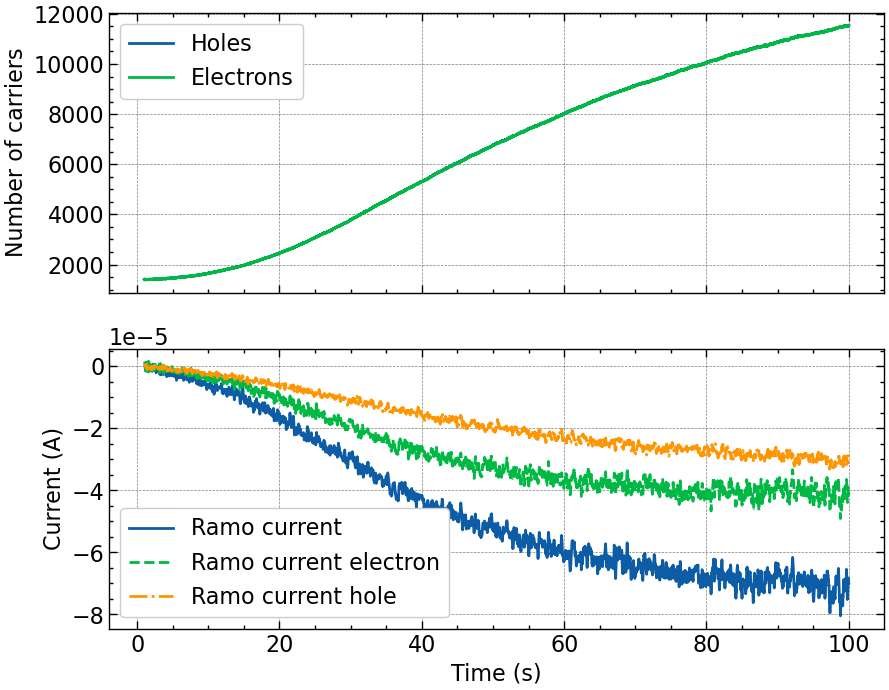

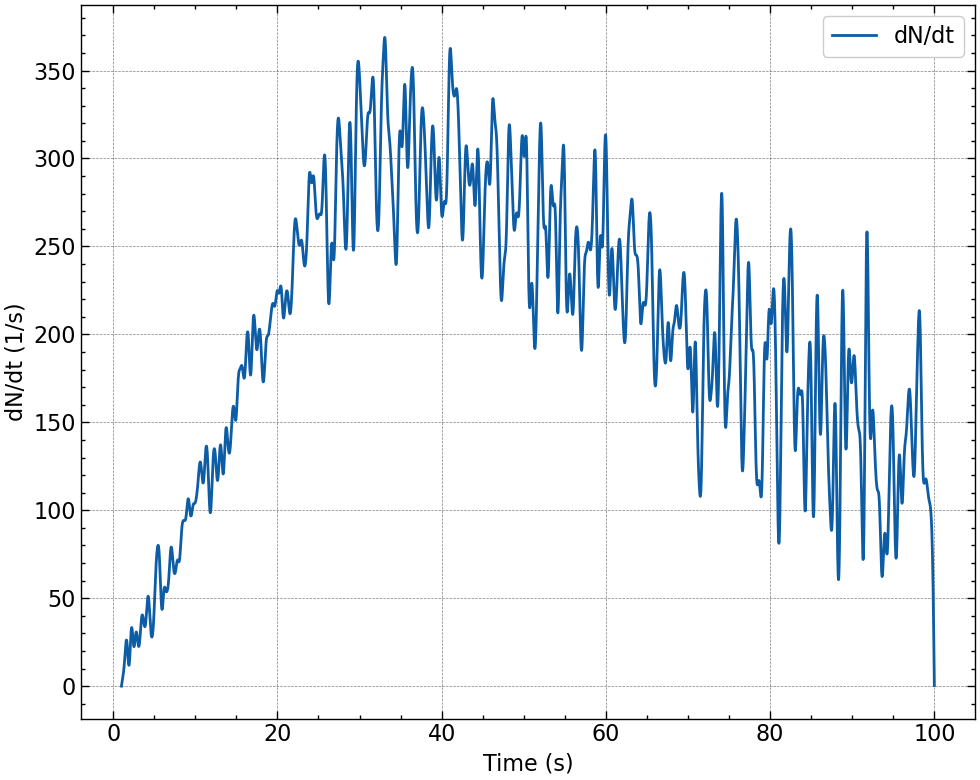

In [178]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig2, axs2 = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
Nsmooth = 100
for file in files:
    time,nb_electrons,nb_holes,nb_impact_ionization,ramo_current_electron,ramo_current_hole,ramo_current,max_electric_field = np.loadtxt(file, delimiter=",", skiprows=1, unpack=True)
    time *= 1e12 # convert to ps
    tmin = 1.0
    argtmin = time > tmin
    time = time[argtmin]
    nb_electrons = nb_electrons[argtmin]
    nb_holes = nb_holes[argtmin]
    nb_impact_ionization = nb_impact_ionization[argtmin]
    ramo_current_electron = ramo_current_electron[argtmin]
    ramo_current_hole = ramo_current_hole[argtmin]
    ramo_current = ramo_current[argtmin]
    max_electric_field = max_electric_field[argtmin]
    time_smooth, ramo_current_smooth = moving_average(time, ramo_current, Nsmooth)
    time_smooth_electron, ramo_current_electron_smooth = moving_average(time, ramo_current_electron, Nsmooth)
    time_smooth_hole, ramo_current_hole_smooth = moving_average(time, ramo_current_hole, Nsmooth)

    axs[0].plot(time, nb_holes, label="Holes")
    axs[0].plot(time, nb_electrons, label="Electrons")
    axs[1].plot(time_smooth, ramo_current_smooth, label="Ramo current")
    axs[1].plot(time_smooth_electron, ramo_current_electron_smooth, '--', label="Ramo current electron")
    axs[1].plot(time_smooth_hole, ramo_current_hole_smooth, '-.', label="Ramo current hole")
    
    # Diff nb carriers
    sigma = 200
    smooth_nb_electrons = scipy.ndimage.gaussian_filter1d(nb_electrons, sigma=sigma)
    smooth_nb_holes = scipy.ndimage.gaussian_filter1d(nb_holes, sigma=sigma)
    d_nb_carriers_dt = np.gradient(smooth_nb_electrons + smooth_nb_holes, time)
    axs2.plot(time, d_nb_carriers_dt, label="dN/dt")

axs[-1].set_xlabel("Time (s)")
axs[0].set_ylabel("Number of carriers")
axs[0].legend()
axs[1].set_ylabel("Current (A)")
axs[1].legend()

axs2.set_xlabel("Time (s)")
axs2.set_ylabel("dN/dt (1/s)")
axs2.legend()

plt.tight_layout()
plt.show()